<a href="https://colab.research.google.com/github/deepshresthaa/A-Clustered-Graph-Based-Framework-for-Semantic-Research-Paper-Retrieval-and-Recommendation/blob/main/code/03_forming_graphical_representation_and_training_cluster0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.5 MB/s eta 0:00:00


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/papers_clustered.parquet'

df = pd.read_parquet(file_path)

df.head()

Mounted at /content/drive


,id,title,category,summary,embedding,pca_embedding,cluster
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,Because of their occasional need to return to ...,"[0.016953887, 0.060273074, -0.03308823, 0.0273...","[-0.02339239791035652, -0.3895048499107361, -0...",16
1,cs-9308102v1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,Market price systems constitute a well-underst...,"[0.005659196, 0.03871944, -0.05143565, -0.0469...","[0.033656246960163116, -0.5250285863876343, -0...",12
2,cs-9309101v1,An Empirical Analysis of Search in GSAT,Artificial Intelligence,We describe an extensive study of search in GS...,"[-0.0076389345, -0.011536828, -0.024900155, -0...","[0.1429884433746338, -0.45451390743255615, -0....",12
3,cs-9311101v1,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,As real logic programmers normally use cut (!)...,"[-0.0024742228, 0.03417379, -0.02816961, 0.026...","[0.2859783172607422, -0.3050631880760193, -0.1...",12
4,cs-9311102v1,Software Agents: Completing Patterns and Const...,Artificial Intelligence,To support the goal of allowing users to recor...,"[0.04028217, -0.041410014, -0.0010439544, -0.0...","[0.35329899191856384, -0.17816203832626343, -0...",28


In [ ]:
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm  # Import progress bar

def find_optimal_threshold(cluster_embeddings, threshold_range=np.arange(0.3, 0.85, 0.05)):
    """
    Evaluates graph connectivity across similarity thresholds.
    Target: Highest clustering coefficient while maintaining average degree ~ 5-15.
    """
    # Compute pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(cluster_embeddings)
    np.fill_diagonal(sim_matrix, 0) # Exclude self-loops

    results = []

    # Wrap threshold_range with tqdm to show progress bar
    for thresh in tqdm(threshold_range, desc="Evaluating Thresholds"):
        adj = (sim_matrix >= thresh).astype(int)
        G = nx.from_numpy_array(adj)

        num_edges = G.number_of_edges()
        avg_degree = (2 * num_edges) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0

        # Skip heavy clustering calculation if the graph is a giant messy hairball (> 20,000 edges)
        if 0 < num_edges < 20000:
            clustering_coeff = nx.average_clustering(G)
        else:
            clustering_coeff = 0.0

        num_components = nx.number_connected_components(G)

        results.append({
            "threshold": round(thresh, 2),
            "edges": num_edges,
            "avg_degree": round(avg_degree, 2),
            "clustering_coeff": round(clustering_coeff, 4),
            "components": num_components
        })

    res_df = pd.DataFrame(results)
    print("\n--- Threshold Connectivity Analysis ---")
    print(res_df.to_string(index=False))

    return res_df

# Example run on Cluster 0 embeddings
cluster_0_df = df[df["cluster"] == 0]
embeddings_c0 = np.vstack(cluster_0_df["pca_embedding"].values)
threshold_stats = find_optimal_threshold(embeddings_c0)

Evaluating Thresholds: 100%|██████████| 11/11 [00:56<00:00,  5.16s/it]


--- Threshold Connectivity Analysis ---
 threshold   edges  avg_degree  clustering_coeff  components
      0.30 3809799     2209.86             0.000           1
      0.35 3072456     1782.17             0.000           1
      0.40 2337092     1355.62             0.000           1
      0.45 1664424      965.44             0.000           1
      0.50 1094833      635.05             0.000           3
      0.55  656841      381.00             0.000           9
      0.60  351601      203.94             0.000          32
      0.65  163782       95.00             0.000         127
      0.70   64350       37.33             0.000         401
      0.75   20200       11.72             0.000         975
      0.80    4783        2.77             0.149        1883


In [ ]:
import torch
import numpy as np
from torch_geometric.data import Data

def build_cluster_graph(cluster_df, threshold=0.75):
    embeddings = np.vstack(cluster_df["pca_embedding"].values).astype(np.float32)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    x = torch.tensor(embeddings, dtype=torch.float, device=device)

    x_norm = torch.nn.functional.normalize(x, p=2, dim=1)
    sim_matrix = torch.mm(x_norm, x_norm.t())
    sim_matrix.fill_diagonal_(0)

    src, dst = torch.where(sim_matrix >= threshold)
    edge_index = torch.stack([src, dst], dim=0)
    edge_weight = sim_matrix[src, dst]

    # Store paper metadata attributes directly on the Data object
    data = Data(
        x=x.cpu(),
        edge_index=edge_index.cpu(),
        edge_attr=edge_weight.cpu(),
        paper_ids=cluster_df["id"].values,
        titles=cluster_df["title"].values,
        categories=cluster_df["category"].values,
        summaries=cluster_df["summary"].values  # Paper abstract/summary
    )
    return data

c0_graph = build_cluster_graph(cluster_0_df, threshold=0.75)
print("Graph structure for Cluster 0:", c0_graph)

Graph structure for Cluster 0: Data(x=[3448, 100], edge_index=[2, 40400], edge_attr=[40400], paper_ids=[3448], titles=[3448], categories=[3448], summaries=[3448])


In [ ]:
import optuna
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

def objective(trial):
    # 1. Define hyperparameter search space for TPE
    lr = trial.suggest_float("lr", 1e-3, 0.1, log=True)
    hidden_channels = trial.suggest_categorical("hidden_channels", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    # 2. Initialize model with trial parameters
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ClusterGraphSAGE(
        in_channels=c0_graph.num_features,  # <--- CHANGE THIS (was 768)
        hidden_channels=hidden_channels,
        out_channels=128
    ).to(device)

    data = c0_graph.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # 3. Quick training loop (e.g., 30 epochs per trial for fast search)
    model.train()
    epochs = 30
    final_loss = float('inf')

    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)

        # Loss calculation
        edge_src, edge_dst = data.edge_index[0], data.edge_index[1]
        pos_loss = -F.logsigmoid((out[edge_src] * out[edge_dst]).sum(dim=-1)).mean()
        neg_dst = torch.randint(0, data.num_nodes, (edge_src.size(0),), device=device)
        neg_loss = -F.logsigmoid(-(out[edge_src] * out[neg_dst]).sum(dim=-1)).mean()

        loss = pos_loss + neg_loss
        loss.backward()
        optimizer.step()
        final_loss = loss.item()

    return final_loss

# 4. Run the Optuna TPE study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)  # Adjust number of trials as needed

print("\n--- Best Hyperparameters Found ---")
print(study.best_params)
print(f"Lowest Loss Achieved: {study.best_value:.4f}")

[I 2026-08-22 10:34:18,298] A new study created in memory with name: no-name-29d47057-2960-4baf-b3a1-caa884bf85c8
[I 2026-08-22 10:34:18,539] Trial 0 finished with value: 1.0668997764587402 and parameters: {'lr': 0.011865043667687725, 'hidden_channels': 512, 'dropout': 0.4292557427712983}. Best is trial 0 with value: 1.0668997764587402.
[I 2026-08-22 10:34:18,772] Trial 1 finished with value: 1.016768217086792 and parameters: {'lr': 0.0022306010068035473, 'hidden_channels': 512, 'dropout': 0.24667777444112177}. Best is trial 1 with value: 1.016768217086792.
[I 2026-08-22 10:34:19,007] Trial 2 finished with value: 1.0287843942642212 and parameters: {'lr': 0.0066211841129298205, 'hidden_channels': 512, 'dropout': 0.2208134320691776}. Best is trial 1 with value: 1.016768217086792.
[I 2026-08-22 10:34:19,181] Trial 3 finished with value: 1.0998982191085815 and parameters: {'lr': 0.042935460948091975, 'hidden_channels': 256, 'dropout': 0.42896074945005447}. Best is trial 1 with value: 1.016


--- Best Hyperparameters Found ---
{'lr': 0.003150814986349135, 'hidden_channels': 512, 'dropout': 0.2671831274353253}
Lowest Loss Achieved: 1.0121



--- Training Fold 1/5 ---
Epoch 20/5000 | Train Loss: 1.0448 | Val Accuracy: 0.9550
Epoch 40/5000 | Train Loss: 1.0171 | Val Accuracy: 0.9645
Epoch 60/5000 | Train Loss: 1.0057 | Val Accuracy: 0.9618
Epoch 80/5000 | Train Loss: 1.0012 | Val Accuracy: 0.9624
Epoch 100/5000 | Train Loss: 0.9992 | Val Accuracy: 0.9582
Epoch 120/5000 | Train Loss: 0.9970 | Val Accuracy: 0.9620
Epoch 140/5000 | Train Loss: 0.9954 | Val Accuracy: 0.9589
Early stopping triggered at epoch 140 (No validation improvement).

--- Training Fold 2/5 ---
Epoch 20/5000 | Train Loss: 1.0385 | Val Accuracy: 0.9626
Epoch 40/5000 | Train Loss: 1.0159 | Val Accuracy: 0.9626
Epoch 60/5000 | Train Loss: 1.0017 | Val Accuracy: 0.9694
Epoch 80/5000 | Train Loss: 1.0001 | Val Accuracy: 0.9644
Epoch 100/5000 | Train Loss: 0.9987 | Val Accuracy: 0.9615
Epoch 120/5000 | Train Loss: 0.9947 | Val Accuracy: 0.9608
Epoch 140/5000 | Train Loss: 0.9904 | Val Accuracy: 0.9610
Epoch 160/5000 | Train Loss: 0.9921 | Val Accuracy: 0.9616
Ea

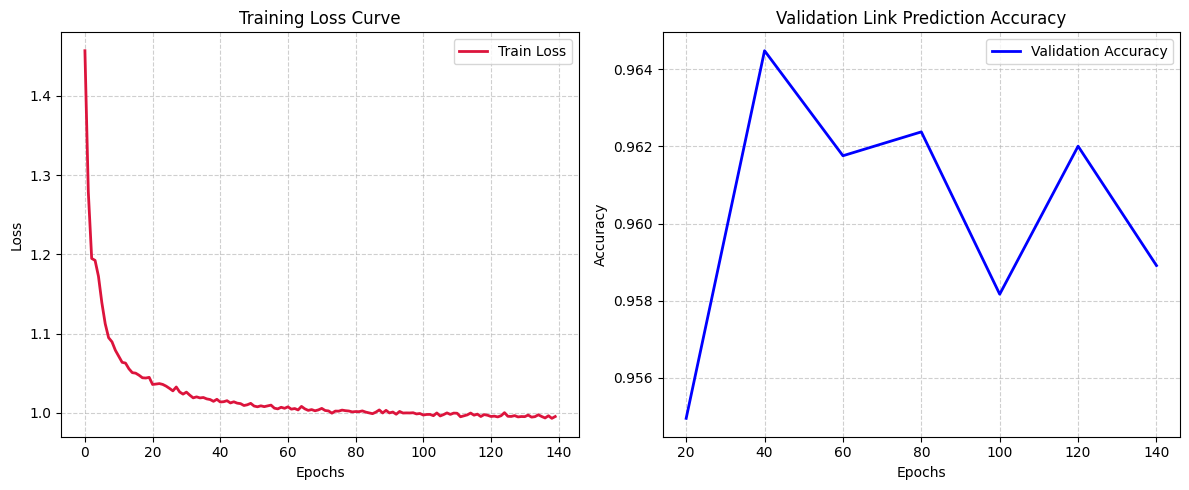


--- Training final model on all edges to generate embeddings ---


Generating Final Embeddings: 100%|██████████| 300/300 [00:02<00:00, 139.28it/s]

Cross-validation completed and final embeddings generated successfully! Shape: torch.Size([3448, 128])


In [ ]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv


class ClusterGraphSAGE(nn.Module):

  def __init__(self, in_channels, hidden_channels, out_channels):
    super().__init__()
    self.conv1 = SAGEConv(in_channels, hidden_channels)
    self.conv2 = SAGEConv(hidden_channels, out_channels)

  def forward(self, x, edge_index):
    x = self.conv1(x, edge_index)
    x = F.relu(x)
    x = F.dropout(x, p=0.22, training=self.training)
    x = self.conv2(x, edge_index)
    return F.normalize(x, p=2, dim=1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
graph_data = c0_graph.to(device)

# --- K-Fold Cross Validation & Metric Tracking ---
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
edge_index = graph_data.edge_index
num_edges = edge_index.size(1)
edge_indices = np.arange(num_edges)
epochs = 5000
fold_history = []

for fold, (train_idx, val_idx) in enumerate(kf.split(edge_indices)):
  print(f'\n--- Training Fold {fold + 1}/{k_folds} ---')
  train_edges = edge_index[:, train_idx]
  val_edges = edge_index[:, val_idx]

  model = ClusterGraphSAGE(
    in_channels=c0_graph.num_features,
    hidden_channels=512,
    out_channels=128
  ).to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  train_losses, val_accuracies = [], []

  # --- Early Stopping Configuration ---
  patience = 5  # Evaluation checks to wait for improvement
  best_val_acc = 0.0
  patience_counter = 0

  for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(graph_data.x, train_edges)

    src, dst = train_edges[0], train_edges[1]
    pos_score = (out[src] * out[dst]).sum(dim=-1)
    pos_loss = -F.logsigmoid(pos_score).mean()

    neg_dst = torch.randint(
        0, graph_data.num_nodes, (src.size(0),), device=device
    )
    neg_score = (out[src] * out[neg_dst]).sum(dim=-1)
    neg_loss = -F.logsigmoid(-neg_score).mean()

    loss = pos_loss + neg_loss
    loss.backward()
    optimizer.step()

    loss_val = loss.item()
    train_losses.append(loss_val)

    # Evaluation / Accuracy check every 20 epochs
    if (epoch + 1) % 20 == 0:
      model.eval()
      with torch.no_grad():
        val_src, val_dst = val_edges[0], val_edges[1]
        val_neg_dst = torch.randint(
            0, graph_data.num_nodes, (val_src.size(0),), device=device
        )
        v_pos = (out[val_src] * out[val_dst]).sum(dim=-1)
        v_neg = (out[val_src] * out[val_neg_dst]).sum(dim=-1)

        acc = (v_pos > v_neg).float().mean().item()
        val_accuracies.append(acc)

        print(
            f'Epoch {epoch + 1}/{epochs} | Train Loss: {loss_val:.4f} | Val'
            f' Accuracy: {acc:.4f}'
        )

        # --- Early Stopping Logic ---
        if acc > best_val_acc:
          best_val_acc = acc
          patience_counter = 0  # Reset patience on improvement
        else:
          patience_counter += 1

        if patience_counter >= patience:
          print(
              f'Early stopping triggered at epoch {epoch + 1} (No validation'
              ' improvement).'
          )
          break

  fold_history.append(
      {'fold': fold + 1, 'losses': train_losses, 'accuracies': val_accuracies}
  )

# --- Plotting Training Curve (Fold 1) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(
    fold_history[0]['losses'], label='Train Loss', color='crimson', linewidth=2
)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
epochs_range = range(20, 20 * len(fold_history[0]['accuracies']) + 1, 20)
plt.plot(
    epochs_range,
    fold_history[0]['accuracies'],
    label='Validation Accuracy',
    color='b',
    linewidth=2,
)
plt.title('Validation Link Prediction Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# --- Final Full Training & Embedding Generation ---
print('\n--- Training final model on all edges to generate embeddings ---')
model.train()
for epoch in tqdm(range(300), desc='Generating Final Embeddings'):
  optimizer.zero_grad()
  out = model(graph_data.x, graph_data.edge_index)
  edge_src, edge_dst = graph_data.edge_index[0], graph_data.edge_index[1]
  pos_loss = -F.logsigmoid(
      (out[edge_src] * out[edge_dst]).sum(dim=-1)
  ).mean()
  neg_dst = torch.randint(
      0, graph_data.num_nodes, (edge_src.size(0),), device=device
  )
  neg_loss = -F.logsigmoid(
      -(out[edge_src] * out[neg_dst]).sum(dim=-1)
  ).mean()
  loss = pos_loss + neg_loss
  loss.backward()
  optimizer.step()

refined_node_embeddings = out.detach()
print(
    'Cross-validation completed and final embeddings generated successfully!'
    f' Shape: {refined_node_embeddings.shape}'
)

In [ ]:
import pandas as pd

# 1. Load the parquet file containing your cluster centers
centers_df = pd.read_parquet(
    '/content/drive/MyDrive/cluster_centers.parquet'
)  # Update path if needed

# 2. Extract only the feature channels as a 2D numpy array (shape: 45, 100)
cluster_centers = centers_df.drop(columns=['cluster']).to_numpy()

In [ ]:
import scipy.sparse as sp

def localized_p_q_search(
    query_vector,
    graph_data,
    gnn_embeddings,
    centers,
    p=1.0,
    q=0.5,
    max_depth=3,
    rel_decay_cutoff=0.15
):
    """
    1. Finds closest cluster center.
    2. Identifies seed paper inside cluster.
    3. Runs second-order biased Random Walk with Restarts (governed by p and q).
    4. Dynamically stops when relevance drop exceeds rel_decay_cutoff.
    """
    # Step 1: Centroid routing
# Convert query vector and push to the same device as graph_data
    query_tensor = torch.tensor(query_vector, dtype=torch.float32).to(graph_data.x.device)
    cluster_sims = centers @ query_vector
    target_cluster = int(np.argmax(cluster_sims))

    # Step 2: Seed paper selection inside target cluster using GNN embedding space
    # Step 2: Seed paper selection using PCA feature space (100-dim vs 100-dim)
    node_sims = torch.cosine_similarity(query_tensor, graph_data.x, dim=1).detach().cpu().numpy()
    seed_idx = int(np.argmax(node_sims))

    # Convert PyG edge index to NetworkX graph for (p, q) biased walk
    G = nx.Graph()
    edges = graph_data.edge_index.cpu().numpy()
    for u, v in zip(edges[0], edges[1]):
        G.add_edge(u, v)

    # Step 3: Biased Breadth-Depth Traversal (Controlled by p and q)
    visited_scores = {}
    queue = [(seed_idx, 0, 1.0)]  # (node_idx, depth, walk_probability)

    while queue:
        curr_node, depth, prob = queue.pop(0)

        if curr_node in visited_scores or depth > max_depth:
            continue

        # Combine structural probability + GNN Semantic Similarity
        combined_score = 0.6 * float(node_sims[curr_node]) + 0.4 * prob
        visited_scores[curr_node] = combined_score

        neighbors = list(G.neighbors(curr_node))
        for nbr in neighbors:
            # p controls return likelihood (DFS behavior), q controls exploration (BFS behavior)
            bias = (1 / p) if nbr == seed_idx else (1 / q)
            next_prob = prob * (1.0 / len(neighbors)) * bias
            queue.append((nbr, depth + 1, next_prob))

    # Sort results by combined score
    ranked_nodes = sorted(visited_scores.items(), key=lambda x: x[1], reverse=True)

    # Step 4: Dynamic Stopping Criterion (Adaptive Cutoff)
    final_selected_papers = []
    prev_score = ranked_nodes[0][1] if ranked_nodes else 0

    for idx, score in ranked_nodes:
        # Stop if score drops sharply relative to previous node score
        if len(final_selected_papers) >= 3 and (prev_score - score) > rel_decay_cutoff:
            break

        final_selected_papers.append({
            "paper_id": graph_data.paper_ids[idx],
            "title": graph_data.titles[idx],
            "score": round(score, 4)
        })
        prev_score = score

    return target_cluster, final_selected_papers

# --- Run Example Query Search ---
dummy_query = embeddings_c0[0]
print(len(dummy_query)) # Simulating a new query embedding
chosen_cluster, recommendations = localized_p_q_search(
    query_vector=dummy_query,
    graph_data=c0_graph,
    gnn_embeddings=refined_node_embeddings,
    centers=cluster_centers
)

print(f"\nRouted to Cluster: {chosen_cluster}")
print(f"Dynamically Selected {len(recommendations)} Papers:")
for rec in recommendations:
    print(f"- [{rec['score']}] {rec['title']}")

100

Routed to Cluster: 0
Dynamically Selected 5 Papers:
- [1.0] Modeling Social Annotation: a Bayesian Approach
- [0.857] Two-Way Latent Grouping Model for User Preference Prediction
- [0.853] Multi-Modal Bayesian Embeddings for Learning Social Knowledge Graphs
- [0.8349] Latent Topic Models for Hypertext
- [0.8146] Non-parametric clustering over user features and latent behavioral
  functions with dual-view mixture models


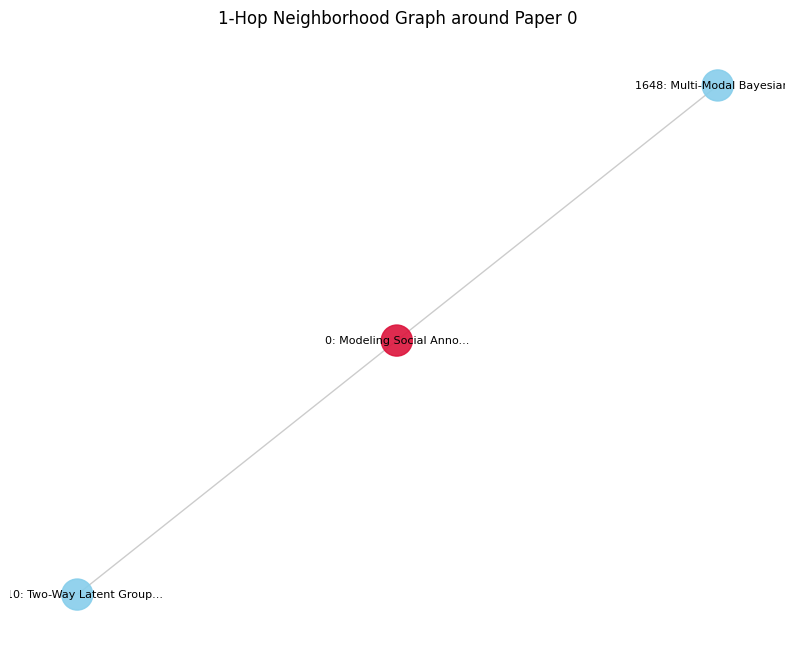

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import torch_geometric.utils as utils

# 1. Convert PyG Data to NetworkX Graph
# Undirected=True handles bidirectional PyG edges cleanly
G = utils.to_networkx(c0_graph, to_undirected=True)

# Assign paper titles as node attributes for labeling
for idx, title in enumerate(c0_graph.titles):
    G.nodes[idx]['title'] = title

# -------------------------------------------------------------
# OPTION A: Visualize the Local Subgraph (Query Paper + Neighbors)
# -------------------------------------------------------------
seed_node = 0  # Index of your query paper ("Modeling Social Annotation...")
k_hop_nodes, _, _, _ = utils.k_hop_subgraph(node_idx=seed_node, num_hops=1, edge_index=c0_graph.edge_index)

# Extract subgraph
sub_G = G.subgraph(k_hop_nodes.tolist())

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub_G, seed=42)  # Force-directed layout

# Draw nodes (highlight query paper in red, neighbors in skyblue)
node_colors = ['crimson' if n == seed_node else 'skyblue' for n in sub_G.nodes()]
nx.draw_networkx_nodes(sub_G, pos, node_size=500, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(sub_G, pos, alpha=0.4, edge_color='gray')

# Draw labels (shortened titles)
labels = {n: f"{n}: {sub_G.nodes[n]['title'][:20]}..." for n in sub_G.nodes()}
nx.draw_networkx_labels(sub_G, pos, labels=labels, font_size=8)

plt.title(f"1-Hop Neighborhood Graph around Paper {seed_node}", fontsize=12)
plt.axis('off')
plt.show()



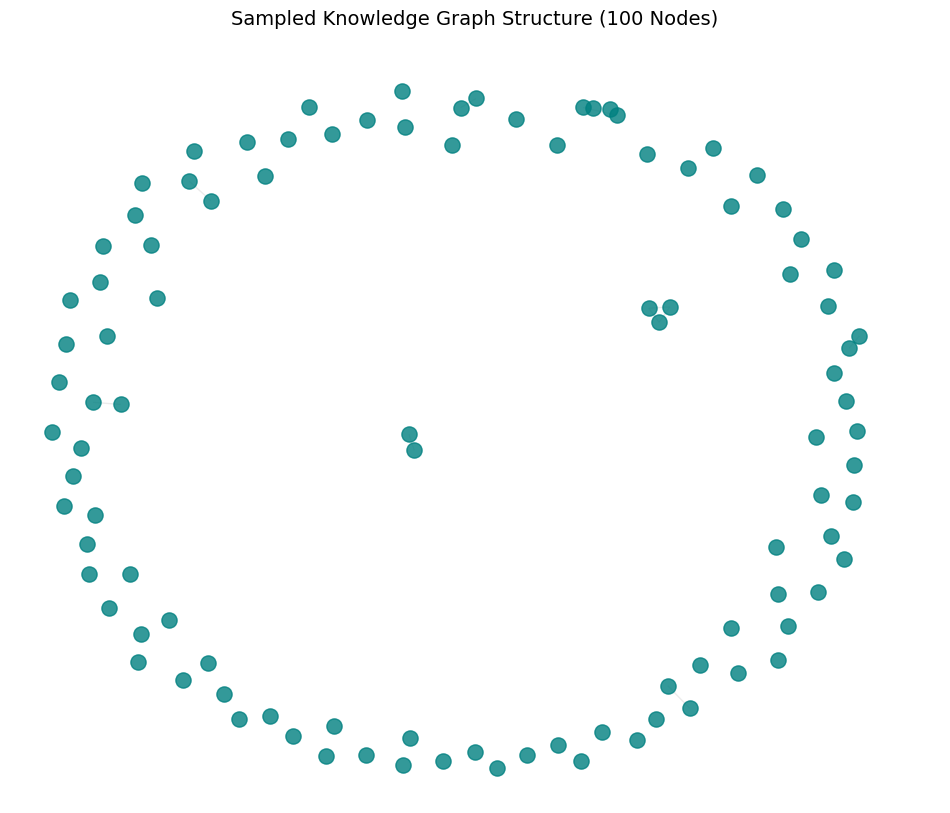

In [ ]:
import random

sample_nodes = random.sample(list(G.nodes()), 100)
sampled_G = G.subgraph(sample_nodes)

plt.figure(figsize=(12, 10))
pos_sample = nx.spring_layout(sampled_G, k=0.15, seed=42)

nx.draw_networkx_nodes(sampled_G, pos_sample, node_size=120, node_color='teal', alpha=0.8)
nx.draw_networkx_edges(sampled_G, pos_sample, alpha=0.3, edge_color='silver')

plt.title("Sampled Knowledge Graph Structure (100 Nodes)", fontsize=14)
plt.axis('off')
plt.show()

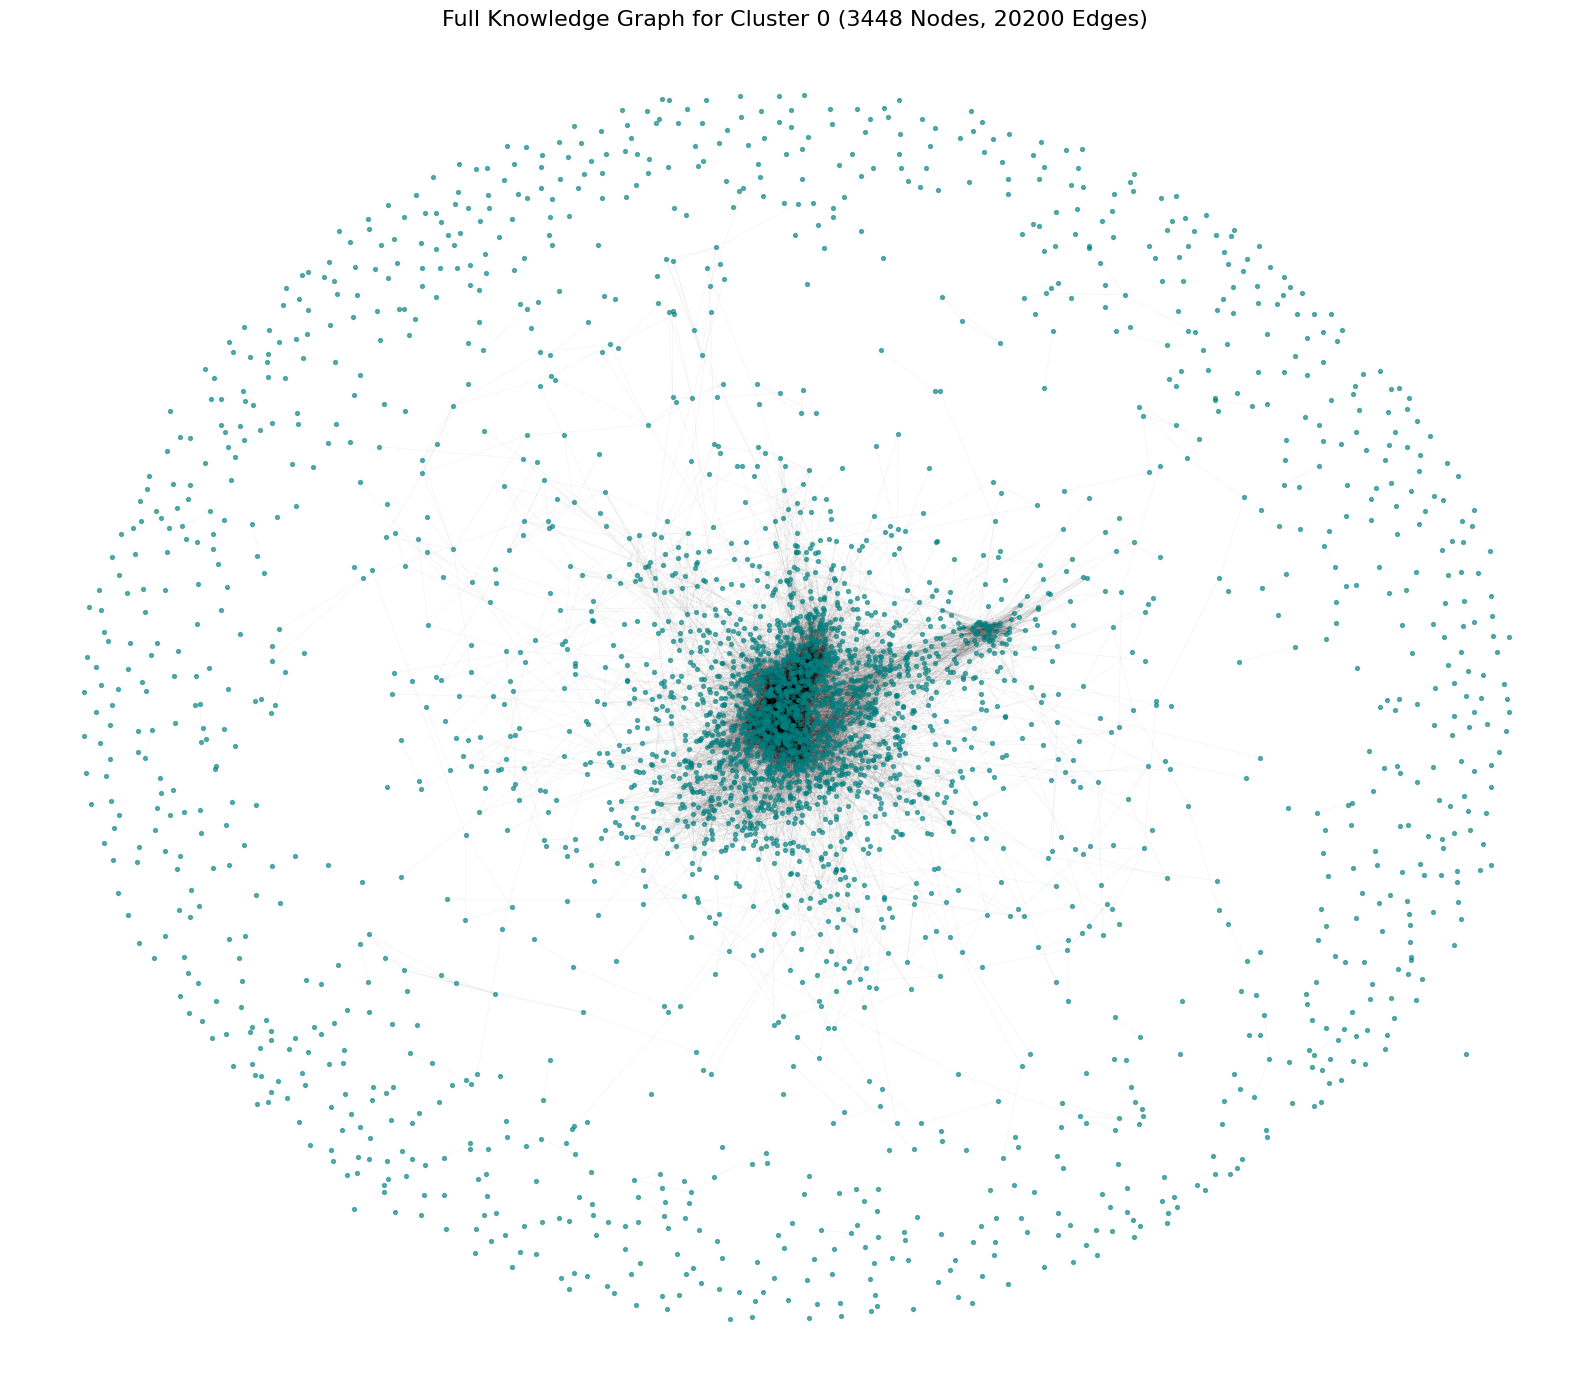

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import torch_geometric.utils as utils

# 1. Convert full PyG Data object to NetworkX Graph
G = utils.to_networkx(c0_graph, to_undirected=True)

# 2. Setup figure
plt.figure(figsize=(16, 14))

# 3. Compute layout (spring layout positions nodes based on connection strength)
pos = nx.spring_layout(G, k=0.08, iterations=20, seed=42)

# 4. Draw edges with high transparency
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.05,
    edge_color='black',
    width=0.5
)

# 5. Draw nodes with small size
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=8,
    node_color='teal',
    alpha=0.6
)

plt.title(f"Full Knowledge Graph for Cluster 0 ({G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import torch
import pickle

# 1. Save PyTorch Geometric Graph Object (contains x, edge_index, paper_ids, summaries, categories, titles)
torch.save(c0_graph, 'c0_graph.pt')

# 2. Save Trained GNN Model Weights
torch.save(model.state_dict(), 'graphsage_model.pt')

# 3. Save Node Index-to-Metadata Mapping Dictionary
metadata = {
    'paper_ids': c0_graph.paper_ids,
    'titles': c0_graph.titles,
    'categories': c0_graph.categories,
    'summaries': c0_graph.summaries
}

with open('graph_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("GNN model, graph, and node metadata successfully saved!")

GNN model, graph, and node metadata successfully saved!


In [ ]:
# Load the saved graph
loaded_graph = torch.load('c0_graph.pt', weights_only=False)
# Access metadata for node index `i` (e.g., node 0)
node_idx = 0
print("Paper ID:", loaded_graph.paper_ids[node_idx])
print("Title:", loaded_graph.titles[node_idx])
print("Category:", loaded_graph.categories[node_idx])
print("Abstract:", loaded_graph.summaries[node_idx])

Paper ID: abs-0811.1319v2
Title: Modeling Social Annotation: a Bayesian Approach
Category: Artificial Intelligence
Abstract: Collaborative tagging systems, such as Delicious, CiteULike, and others,
allow users to annotate resources, e.g., Web pages or scientific papers, with
descriptive labels called tags. The social annotations contributed by thousands
of users, can potentially be used to infer categorical knowledge, classify
documents or recommend new relevant information. Traditional text inference
methods do not make best use of social annotation, since they do not take into
account variations in individual users' perspectives and vocabulary. In a
previous work, we introduced a simple probabilistic model that takes interests
of individual annotators into account in order to find hidden topics of
annotated resources. Unfortunately, that approach had one major shortcoming:
the number of topics and interests must be specified a priori. To address this
drawback, we extend the model to 

In [ ]:
import pandas as pd

# 1. Inspect first few rows of your metadata
summary_df = pd.DataFrame({
    'paper_id': loaded_graph.paper_ids,
    'title': loaded_graph.titles,
    'category': loaded_graph.categories,
    'abstract': loaded_graph.summaries
})

print(f"Total Paper Nodes: {len(summary_df)}")
print("\n--- Category Breakdown ---")
print(summary_df['category'].value_counts())

print("\n--- First 5 Papers ---")
summary_df[['paper_id', 'title', 'category']].head()

Total Paper Nodes: 3448

--- Category Breakdown ---
category
Information Retrieval                                     1359
Machine Learning                                          1018
Artificial Intelligence                                    363
Machine Learning (Statistics)                              181
Computation and Language (Natural Language Processing)     131
Computer Vision and Pattern Recognition                    106
Social and Information Networks                             62
Computer Science and Game Theory                            27
Databases                                                   27
Human-Computer Interaction                                  24
Computers and Society                                       20
Distributed, Parallel, and Cluster Computing                13
Methodology (Statistics)                                    12
Multimedia                                                  11
Cryptography and Security                                

,paper_id,title,category
0,abs-0811.1319v2,Modeling Social Annotation: a Bayesian Approach,Artificial Intelligence
1,abs-0909.2376v1,Performing Hybrid Recommendation in Intermodal...,Artificial Intelligence
2,abs-1011.2304v1,Target tracking in the recommender space: Towa...,Artificial Intelligence
3,abs-1012.3280v1,A new Recommender system based on target track...,Artificial Intelligence
4,abs-1101.2378v1,Extracting Features from Ratings: The Role of ...,Artificial Intelligence


In [ ]:
print("--- PyTorch Geometric Graph Summary ---")
print(f"Node Feature Tensor Shape (x): {loaded_graph.x.shape}")
print(f"Edge Index Tensor Shape (edge_index): {loaded_graph.edge_index.shape}")
print(f"Total Undirected Edges: {loaded_graph.num_edges // 2}")
print(f"Average Node Degree: {loaded_graph.num_edges / loaded_graph.num_nodes:.2f}")
print(f"Has Isolated Nodes: {loaded_graph.has_isolated_nodes()}")
print(f"Has Self-Loops: {loaded_graph.has_self_loops()}")

--- PyTorch Geometric Graph Summary ---
Node Feature Tensor Shape (x): torch.Size([3448, 100])
Edge Index Tensor Shape (edge_index): torch.Size([2, 40400])
Total Undirected Edges: 20200
Average Node Degree: 11.72
Has Isolated Nodes: True
Has Self-Loops: False


In [ ]:
import torch
import numpy as np

def localized_graph_search(query_embedding_100d, graph, top_k_anchors=3, max_hops=1, top_n_results=10):
    """
    Performs localized graph search for a new 100-dim query embedding.

    1. Finds top_k_anchors nearest nodes in the graph via cosine similarity.
    2. Collects local N-hop neighbors connected via edge_index.
    3. Ranks and returns top_n_results candidates with metadata.
    """
    device = graph.x.device
    query_tensor = torch.tensor(query_embedding_100d, dtype=torch.float, device=device).unsqueeze(0)

    # 1. Cosine similarity between Query and Graph Nodes
    query_norm = torch.nn.functional.normalize(query_tensor, p=2, dim=1)
    graph_norm = torch.nn.functional.normalize(graph.x.to(device), p=2, dim=1)
    similarities = torch.mm(query_norm, graph_norm.t()).squeeze(0)

    # 2. Get top-K initial anchor nodes
    anchor_scores, anchor_indices = torch.topk(similarities, k=top_k_anchors)
    anchor_set = set(anchor_indices.cpu().numpy())

    # 3. Expand search locally to N-hop neighbors
    candidate_nodes = set(anchor_set)
    edge_index = graph.edge_index.cpu().numpy()

    for _ in range(max_hops):
        new_neighbors = set()
        for node in candidate_nodes:
            # Find destination nodes connected to current node
            neighbors = edge_index[1, edge_index[0] == node]
            new_neighbors.update(neighbors)
        candidate_nodes.update(new_neighbors)

    candidate_indices = torch.tensor(list(candidate_nodes), dtype=torch.long, device=device)

    # 4. Rank candidate nodes by similarity to query
    candidate_sims = similarities[candidate_indices]
    top_scores, top_rank_idx = torch.topk(candidate_sims, k=min(top_n_results, len(candidate_indices)))
    final_node_indices = candidate_indices[top_rank_idx].cpu().numpy()

    # 5. Format localized search results
    results = []
    for rank, node_idx in enumerate(final_node_indices):
        results.append({
            'rank': rank + 1,
            'node_id': int(node_idx),
            'paper_id': graph.paper_ids[node_idx],
            'title': graph.titles[node_idx],
            'category': graph.categories[node_idx],
            'similarity_score': round(float(top_scores[rank]), 4),
            'is_direct_anchor': node_idx in anchor_set
        })

    return results

In [ ]:
# Pass a sample 100-dim query embedding (e.g., from a new paper)
sample_new_embedding = np.random.randn(100).astype(np.float32)

# Run Localized Search
search_results = localized_graph_search(
    query_embedding_100d=sample_new_embedding,
    graph=loaded_graph,
    top_k_anchors=3,    # Find 3 initial anchor nodes
    max_hops=1,          # Traversed 1 hop out in graph structure
    top_n_results=5     # Return top 5 matches
)

# Display Results
for res in search_results:
    anchor_flag = " [Anchor Node]" if res['is_direct_anchor'] else " [Graph Neighbor]"
    print(f"Rank {res['rank']}{anchor_flag}: {res['title']}")
    print(f"   ID: {res['paper_id']} | Score: {res['similarity_score']} | Category: {res['category']}\n")

Rank 1 [Anchor Node]: PROBE-Web: An Interactive System for Probing Evaluation Landscapes of Knowledge Graph Completion Models
   ID: abs-2606.08926v1 | Score: 0.2869 | Category: Machine Learning

Rank 2 [Anchor Node]: Efficient Evaluation of Large Language Models via Collaborative Filtering
   ID: abs-2504.08781v1 | Score: 0.2847 | Category: Computation and Language (Natural Language Processing)

Rank 3 [Anchor Node]: User Preference Modeling for Conversational LLM Agents: Weak Rewards from Retrieval-Augmented Interaction
   ID: abs-2603.20939v1 | Score: 0.274 | Category: Computation and Language (Natural Language Processing)

Rank 4 [Graph Neighbor]: User Behavior Prediction as a Generic, Robust, Scalable, and Low-Cost Evaluation Strategy for Estimating Generalization in LLMs
   ID: abs-2507.05266v1 | Score: 0.2244 | Category: Computation and Language (Natural Language Processing)

Rank 5 [Graph Neighbor]: ITDR: An Instruction Tuning Dataset for Enhancing Large Language Models in Reco